# **Features Engineer - Lựa chọn đặc trưng**

Sau khi đã xây dựng các mô hình cơ sở là Linear Regression Model, chúng tôi đã quyết định sử dụng những mô hình dự đoán dựa trên nhiều features thay vì chỉ dựa vào các chu kỳ, mùa vụ. Vì vậy trong notebooks này, chúng tôi sẽ tập hợp những features có khả năng cao góp phần vào `revenue`, xây dựng một tập dữ liệu huấn luyện mới và tối ưu để cải thiện các mô hình huấn luyện. Tuy nhiên, vì mô hình Linear Regression Model chỉ có tác dụng với các đặc trưng tuyến tính, để có thể đánh giá được cả các đặc trưng trọng số (0/1) thì chúng tôi sẽ sử dụng mô hình CatBoost để đánh giá.
 
- Kiểm tra độ mạnh yếu với các features từ các bảng khác
- Kiểm tra độ mạnh yếu với các features được tạo dựa trên tính mùa vụ
- Lọc bỏ  bớt các features yếu và gây nhiễu
- Tập hợp và huấn luyện mô hình lần cuối


**Mục tiêu**: Xác định được những faetures tốt nhất cho các mô hình sau học tốt hơn

**Mục lục**
1. [Tổng quan](#1)
2. [Đánh giá mức độ tương quan](#2)
3. [Đánh giá dựa trên huấn luyện mô hình](#3)
4. [Xử lý dữ liệu](#4)

<a id = "1"></a>

## 1. Tổng quan

In [11]:
# các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.get_data import get_data_processed
from src.models import run_single_model
from src.visualization import *

MODEL = 'CatBoost'

In [12]:
df = get_data_processed('final_m1.csv')
df.head()

Đã đọc thành công dữ liệu từ: D:\datathon\vimchanhxa-datathon\data\processed\final_m1.csv


,date,revenue,cogs,is_test,order_count,unique_customers,total_quantity,month,day_of_month,day_of_week,...,customer_cr,items_per_order,average_order_value,average_price_per_unit,revenue_lag_7,revenue_lag_28,revenue_lag_364,rm_lag_7,rm_lag_28,rm_lag_364
0,2012-07-04,5123547.94,3982991.19,0,162.0,161.0,777.0,7,4,2,...,1.006211,4.796296,31626.839136,6594.012793,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,2751773.45,2150580.23,0,97.0,97.0,428.0,7,5,3,...,1.000000,4.412371,28368.798454,6429.377220,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,3054029.42,2517632.84,0,93.0,93.0,441.0,7,6,4,...,1.000000,4.741935,32839.026022,6925.236780,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,2667930.94,2108246.62,0,73.0,73.0,364.0,7,7,5,...,1.000000,4.986301,36546.999178,7329.480604,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,2360851.90,1808622.79,0,88.0,87.0,394.0,7,8,6,...,1.011494,4.477273,26827.862500,5992.009898,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4381 entries, 0 to 4380
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    4381 non-null   str    
 1   revenue                 3833 non-null   float64
 2   cogs                    3833 non-null   float64
 3   is_test                 4381 non-null   int64  
 4   order_count             3833 non-null   float64
 5   unique_customers        3833 non-null   float64
 6   total_quantity          3833 non-null   float64
 7   month                   4381 non-null   int64  
 8   day_of_month            4381 non-null   int64  
 9   day_of_week             4381 non-null   int64  
 10  days_since_start        4381 non-null   int64  
 11  seasonal_index          4381 non-null   float64
 12  day_of_week_index       4381 non-null   float64
 13  intra_month_index       4381 non-null   float64
 14  is_peak_season          4381 non-null   int64  
 15

#### Từ Điển Dữ Liệu (Data Dictionary) - Tập Dữ Liệu Đầy Đủ

Dưới đây là giải thích chi tiết ý nghĩa và mục đích sử dụng của toàn bộ các đặc trưng (features) trong tập dữ liệu:

| Tên Đặc Trưng (Feature) | Nhóm | Giải thích chi tiết |
| :--- | :--- | :--- |
| **`date`** | **Thời gian** | Ngày ghi nhận giao dịch. Là cột thời gian cơ sở để sắp xếp chuỗi thời gian. |
| **`revenue`** | **Mục tiêu** | **[Target Variable]** Doanh thu tổng cộng của ngày hôm đó (Biến cần dự đoán). |
| **`cogs`** | **Tài chính** | Giá vốn hàng bán. Thường dùng để tính lợi nhuận gộp. |
| **`month_sin`** | **Mùa vụ** | Tháng trong năm (1 - 12) có tuần hoàn. Giúp mô hình nhận diện chu kỳ tiêu dùng lớn. |
| **`month_cos`** | **Mùa vụ** | Tháng trong năm (1 - 12)có tuần hoàn. Giúp mô hình nhận diện chu kỳ tiêu dùng lớn. |
| **`day_of_month`** | **Mùa vụ (Thô)** | Ngày trong tháng (1 - 31). |
| **`day_of_week`** | **Mùa vụ (Thô)** | Thứ trong tuần (0 - 6). Phân biệt giữa ngày thường và cuối tuần. |
| **`seasonal_index`** | **Mùa vụ (Index)** | Chỉ số mùa vụ tổng quát (VD: `1.2` = sức mua cao hơn trung bình 20%). |
| **`day_of_week_index`** | **Mùa vụ (Index)** | Chỉ số sức mua quy đổi theo từng thứ trong tuần. |
| **`intra_month_index`** | **Mùa vụ (Index)** | Chỉ số biến động sức mua bên trong một tháng (đầu/giữa/cuối tháng). |
| **`sessions`** | **Traffic** | Tổng số lượt truy cập |
| **`conversion_rate`** | **Traffic** | Tỉ lệ số lượt mua thật trên tổng số lần truy cập |
| **`AOV`** | **Hành vi khách hàng** | Giá trị đơn hàng trung bình |
| **`IPO`** | **Hành vi khách hàng** | Số lượng mặt hàng trên từng đơn |
| **`is_Jun`** | **Sự kiện (0/1)** | Đánh dấu tháng 6 (thường lỗ) |
| **`is_Dec`** | **Sự kiện (0/1)** | Đánh dấu tháng 12 (thường không sinh lợi nhuận). |
| **`is_Sep_odd_year`** | **Sự kiện (0/1)** | Đánh dấu tháng 9 năm lẻ. |
| **`is_peak_season`** | **Sự kiện (0/1)** | Đánh dấu ngày nằm trong mùa cao điểm mua sắm (Lễ, Tết, cuối năm...). |
| **`is_weekend`** | **Sự kiện (0/1)** | Đánh dấu ngày cuối tuần. |
| **`is_payday_spike`** | **Sự kiện (0/1)** | Đánh dấu ngày bùng nổ chi tiêu sau kỳ nhận lương. |
| **`is_post_bill_slump`** | **Sự kiện (0/1)** | Đánh dấu giai đoạn "đáy" chi tiêu sau khi thanh toán hóa đơn. |
| **`revenue_lag_7`** | **Quá khứ** | Doanh thu của đúng **7 ngày trước**. Mỏ neo cho dự đoán ngắn hạn. |
| **`revenue_lag_28`** | **Quá khứ** | Doanh thu của đúng **30 ngày trước**. Tính mùa vụ theo tháng. |
| **`revenue_lag_364`** | **Quá khứ** | Doanh thu của đúng **364 ngày trước**. Khớp tính mùa vụ của năm ngoái. |
| **`revenue_rolling_mean_28`** | **Quá khứ** | Doanh thu trung bình mỗi ngày trong **28 ngày qua**. Phản ánh xu hướng (Trend). |
| **`order_count`** | **Hành vi KH** | Tổng số lượng đơn hàng được đặt trong ngày. |
| **`unique_customers`** | **Hành vi KH** | Số lượng khách hàng độc lập (duy nhất) đã mua sắm trong ngày. |
| **`total_quantity`** | **Hành vi KH** | Tổng số lượng sản phẩm (items) được bán ra. |
| **`discount_pct`** | **Khuyến mãi** | Tổng mức giảm giá theo phần trăm (%) được áp dụng trong ngày. |
| **`discount_fixed`** | **Khuyến mãi** | Tổng số tiền giảm giá cố định (Voucher trừ thẳng tiền) được áp dụng. |
| **`is_global_promo`** | **Khuyến mãi** | Biến nhị phân (0/1) báo hiệu có chương trình Sale toàn nền tảng hay không. |
| **`is_specific_promo`** | **Khuyến mãi** | Biến nhị phân (0/1) báo hiệu có chương trình Sale cho danh mục cụ thể hay không. |
| **`total_sessions`** | **Traffic** | Tổng số lượt truy cập (traffic) vào website/nền tảng trong ngày. |

## 2. Đánh giá mức độ tương quan

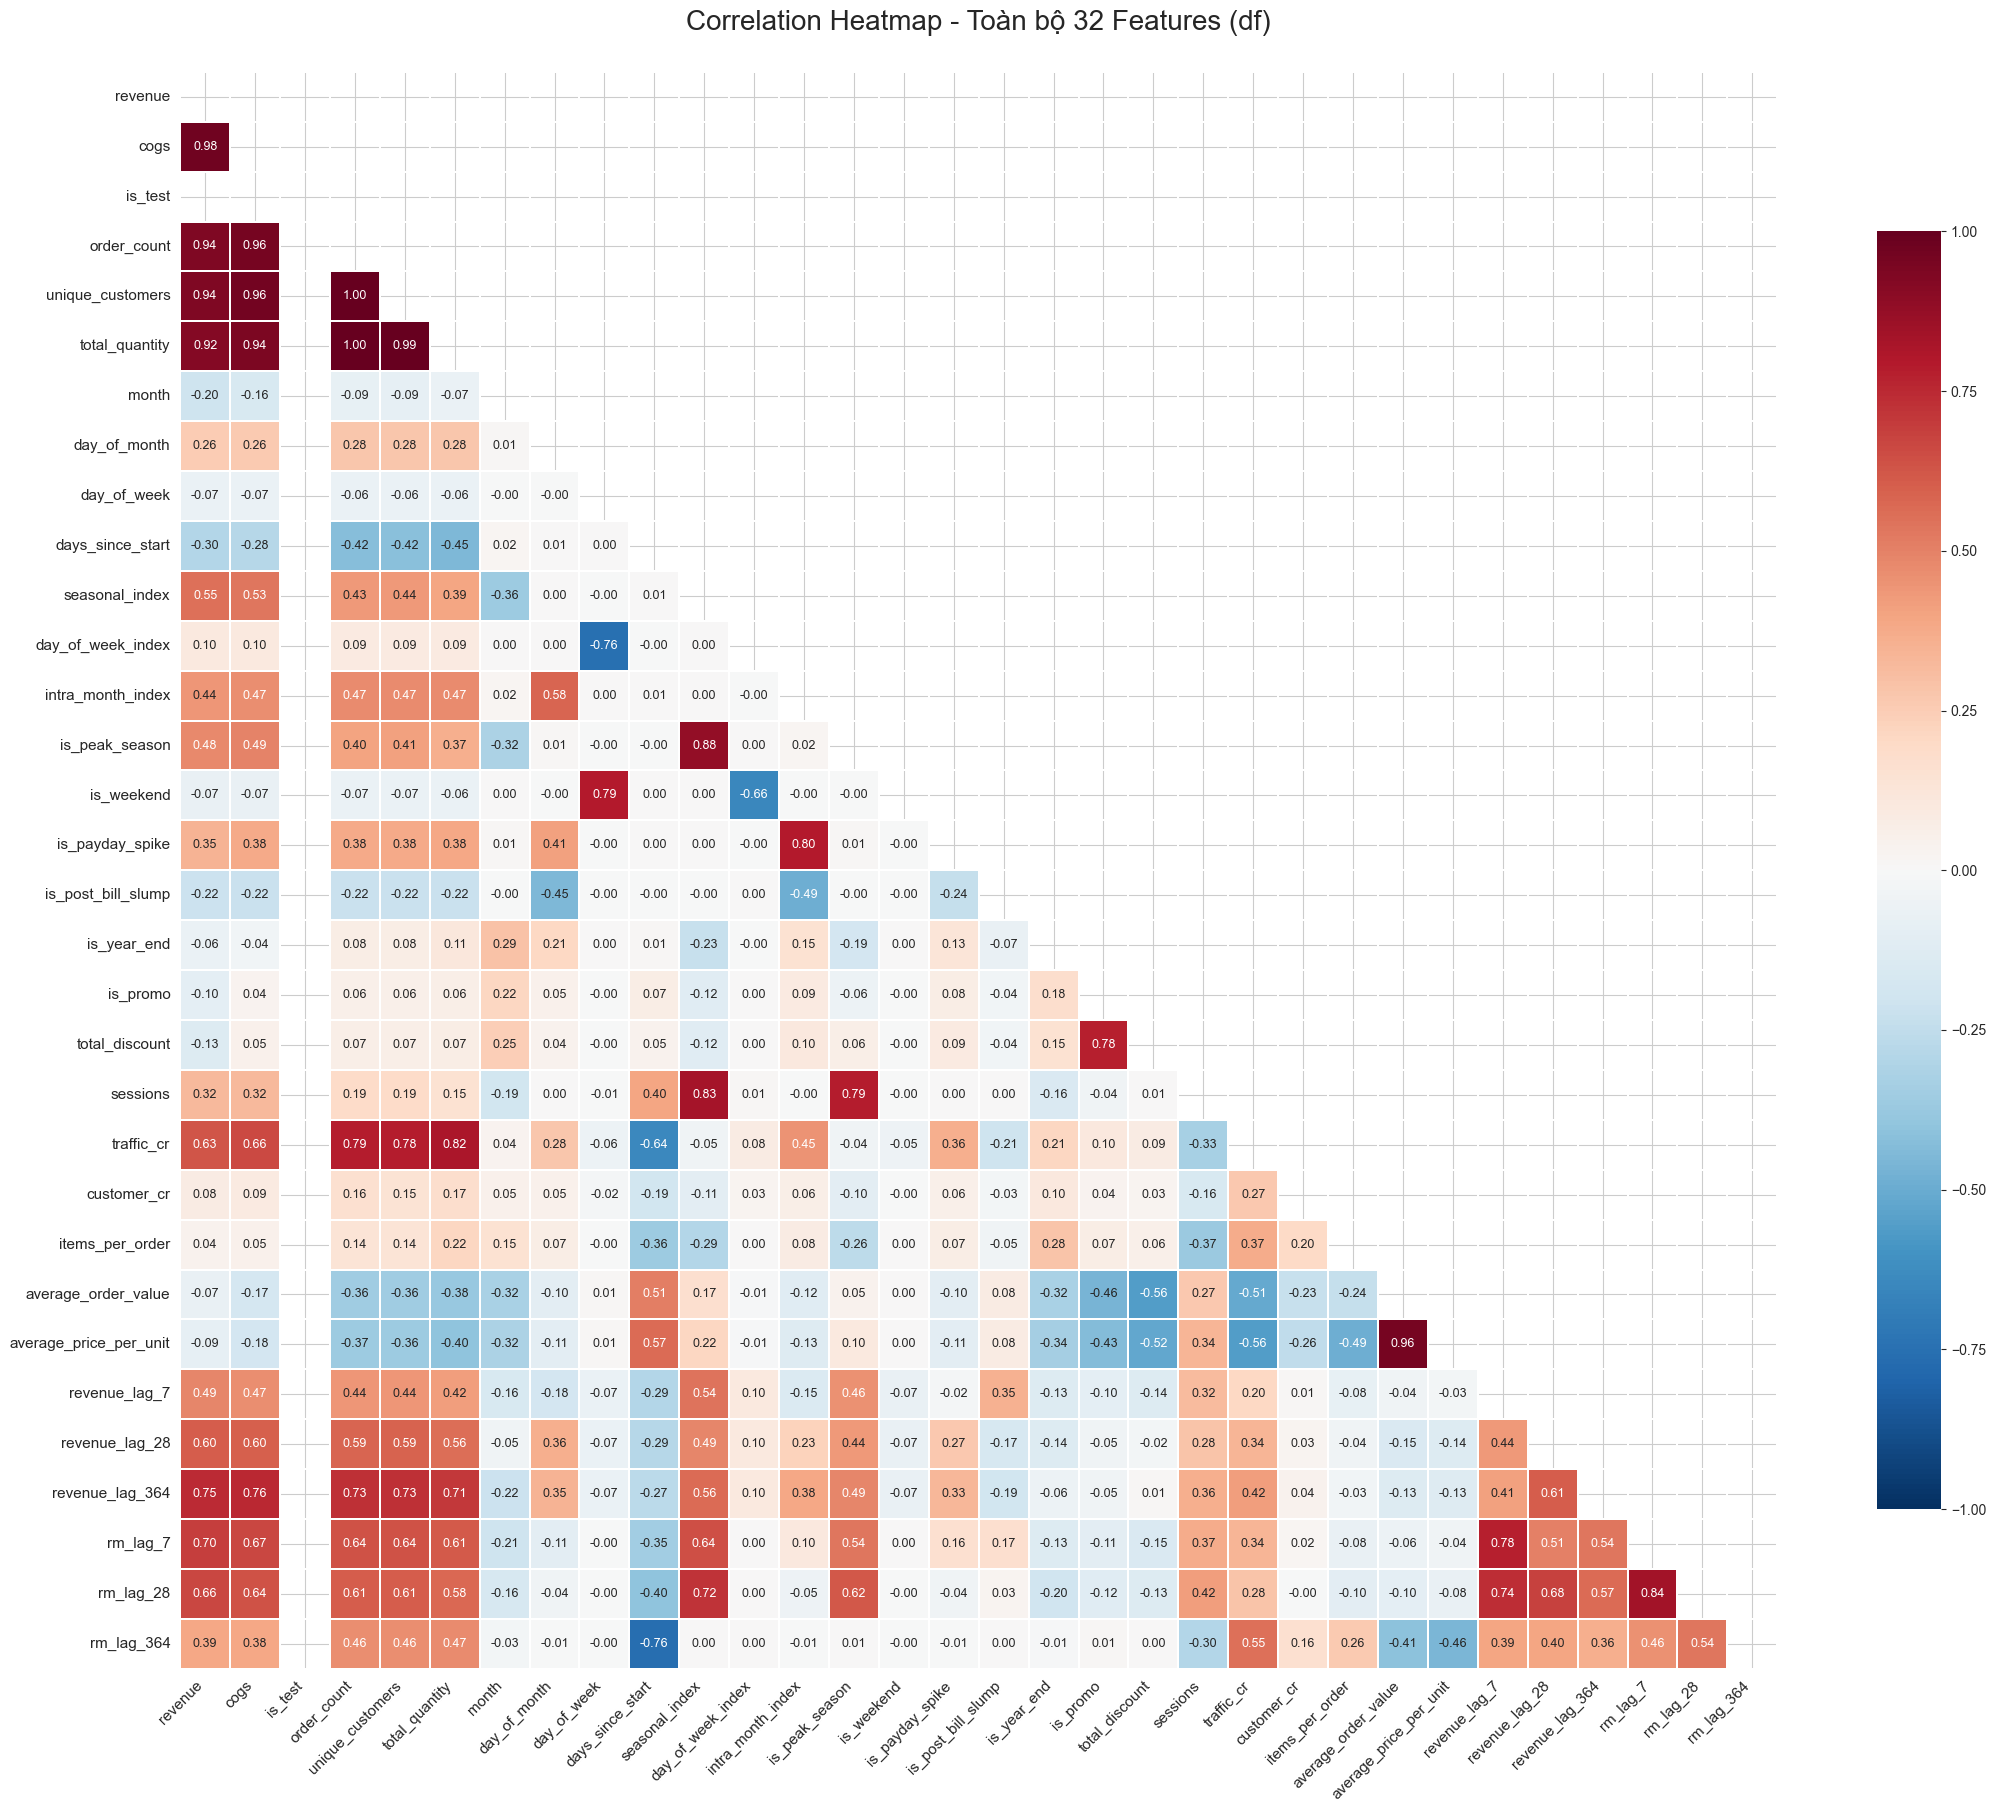

In [14]:
def plot_final_heatmap(df):
    # 1. Chỉ lấy các cột dữ liệu số
    df_numeric = df.select_dtypes(include=[np.number])
    n = len(df_numeric.columns)
    
    # 2. Tính ma trận tương quan
    corr = df_numeric.corr()
    
    # 3. Tạo mask che đi nửa trên để dễ nhìn hơn
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # 4. Thiết lập kích thước lớn (20x16) để hiển thị rõ 26 features
    plt.figure(figsize=(22, 18))
    
    # 5. Vẽ heatmap
    sns.heatmap(
        corr, 
        mask=mask, 
        annot=True,          # Hiện số
        fmt=".2f",           # Lấy 2 chữ số thập phân
        cmap='RdBu_r',       # Màu Đỏ (dương) - Trắng (0) - Xanh (âm)
        center=0,
        vmin=-1, vmax=1,
        square=True, 
        linewidths=.3,
        cbar_kws={"shrink": .8},
        annot_kws={"size": 9} # Cỡ chữ số nhỏ lại để không bị đè nhau
    )
    
    plt.title(f'Correlation Heatmap - Toàn bộ {n} Features (df)', fontsize=20, pad=30)
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.tight_layout()
    plt.show()

# Thực thi vẽ biểu đồ
plot_final_heatmap(df[df['is_test'] == 0])

**Nhật xét**:
- Các đặc trưng có mức độ tương quan cao với `revenue` như : `cogs`,`unique_customers` và `order_count` sẽ được loại bỏ hoặc thay thế bằng mội biến khác liên quan hoặc lùi về quá khứ để tránh mô hình bị overfitting
- `revenue_rolling_mean_90` đang có mức tương quan cao với `revenue_rolling_mean_28`, vì vậy sẽ xóa `revenue_rolling_mean_90`
- `total_quantity` sẽ là một đặc trưng tốt để phân biệt giữa những ngày có giảm giá so với những ngày thường, chúng tôi sẽ tạo một mô hình dự đoán khác để dự đoán cho `total_quantity` trước khi dự đoán `revenue`
- `total_sessions` có mức độ tương quan khác ổn áp, ngoài ra xu hướng của nó có tính mùa vụ và xu hướng tăng lên qua các năm, chúng tôi sẽ khai phá đặc trưng này bằng cách huấn luyện thêm một mô hình nữa để dự đoán `total_sessios` cho tương lai trước khi đưa vào dự đoán `revenue`

In [15]:
drop_cols = []


## 3. Đánh giá dựa trên huấn luyện mô hình

### 3.1 Dự đoán trực tiếp - Revenue

Biến mục tiêu `revenue` có thể sẽ bị ảnh hưởng nhiều yếu tố khác từ các bảng khác, do đó chúng tôi xác định yéu tố nào ảnh hưởng rõ ràng nhất để tạo đặc trưng tốt cho dự đoán `revenue`

In [16]:
target = 'revenue'
features = [col for col in df.columns if col not in ['date', 'cogs', 'order_count', 'unique_customers', 'total_quantity', target]]

In [17]:
# Huấn luyện mô hình với toàn bộ features để xem hiệu quả
val_pre, model, metrics = run_single_model(model_name=MODEL, df=df, target_col=target, feature_cols=features)
print("Kết quả đánh giá trên tập validation:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Kết quả đánh giá trên tập validation:
MAE: 152410.7406
RMSE: 220191.4021
MAPE: 5.1805
R-squared: 0.9827


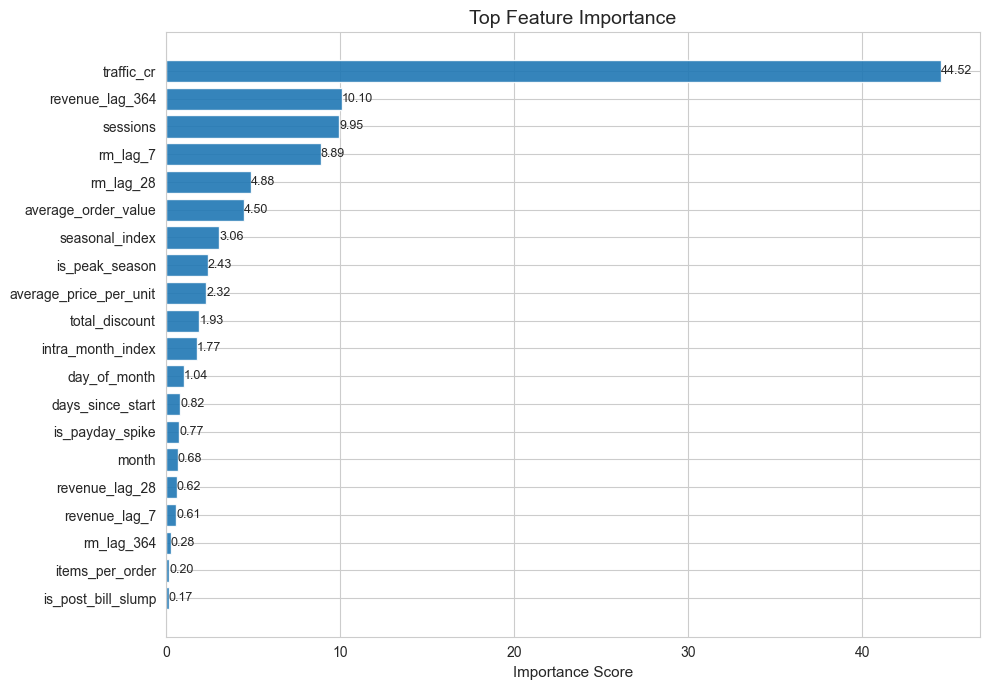

In [18]:
plot_feature_importance(model, features, top_features=20)

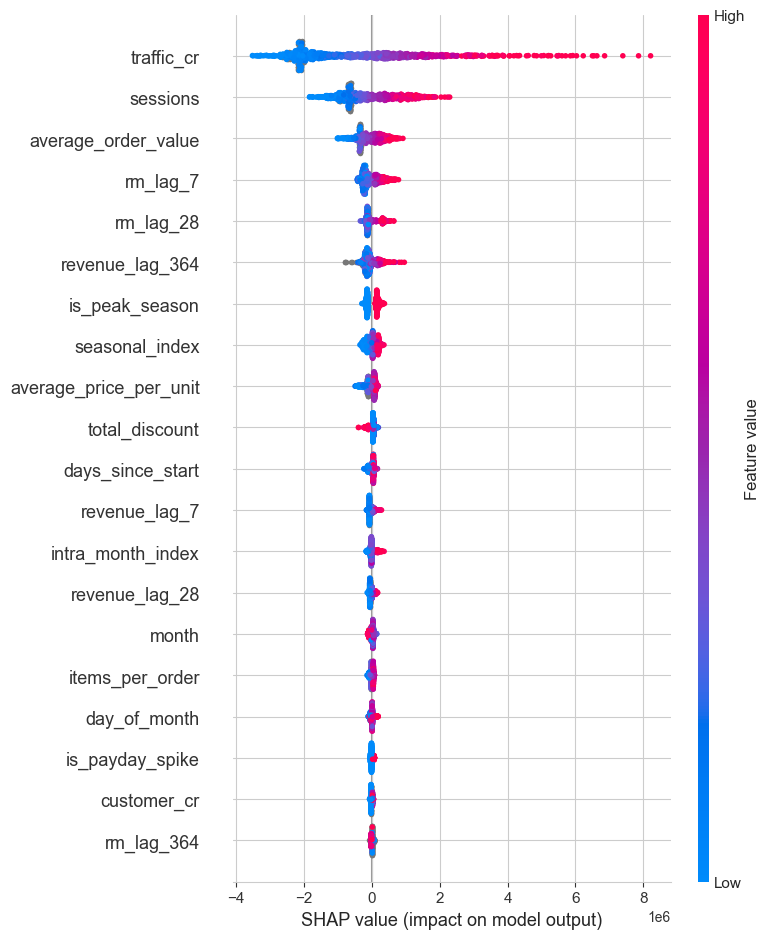

In [19]:
plot_shap_summary(model, df, features=features,  top_features=20)

In [20]:
bad_features = ['discount_amount', 'discount_rate', 'unit_price']

### 3.2 Dự đoán gián tiếp - Quantity, Orders, AOV

### 3.3 Dự đoán lai (Hybrid)

## 4. Xử lý dữ liệu

### 4.1 Dự đoán trực tiếp

### 4.2 Dự đoán gián tiếp

### 4.3 Dự đoán lai - Hybrid

---
**Kết luận:**

Sau notebooks này, chúng tôi đã chọn ra được các `features` tốt nhất, đồng thời chúng tôi đã cải thiện được mô hình LigthGBM từ `26%` xuống còn `18,14%`, điều này đã giúp chúng tôi tự tin hơn khi chọn các models phức tạp sau đó với bộ features này. Ngoài ra, chúng tôi sẽ sử dụng phương pháp Two-Stage Model để dự báo cho các biến phụ khác như `total_sessions` trước khi cho mô hình học, điều này đã giảm đáng kể sai số khi chúng tôi huấn luyện mô hình bằng dữ liệu dự báo này.

Mục tiêu tiếp theo:
- Thực hiện triển khai huấn luyện các mô hình học máy
- Huấn luyện các mô hình dự báo phụ để dự đoán tổng cho `revenue`
- Chọn ra phương pháp tối ưu nhất
- CHuyển sang các mô hình học sâu để tăng sự liên kết giữa các features

**Lưu ý:**

Luôn luôn thêm 2 feature này vào mô hình:
- `month_sin` = sin(2π * month / 12)
- `month_cos` = cos(2π * month / 12)

Để mô hình luôn hiểu rằng với dữ liệu time series, tháng 12 là tuần hoàn với tháng 1

---
**Notebooks tiếp theo:** [07_ML_.ipynb](07_ML_.ipynb) - Lựa chọn mô hình học máy tối ưu